In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
train = pd.read_csv("train.csv")
# test = pd.read_csv("test.csv")

In [39]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
train.shape
# test.shape

(42000, 785)

In [41]:
train.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
9362,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


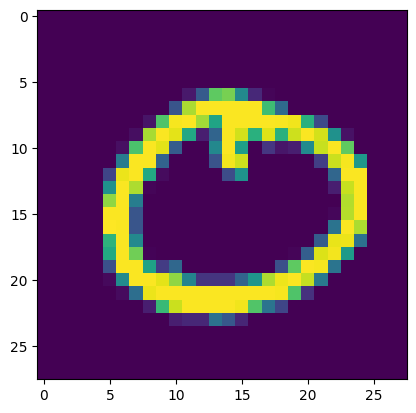

In [42]:
plt.imshow(train.iloc[9362, 1:].values.reshape(28,28))

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X = train.iloc[:,1:]
y = train.iloc[:,0]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [46]:
X_train.shape , y_train.shape

((33600, 784), (33600,))

In [47]:
X_test.shape, y_test.shape

((8400, 784), (8400,))

In [48]:
from sklearn.neighbors import KNeighborsClassifier

In [49]:
knn = KNeighborsClassifier()

In [50]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [51]:
import time
start = time.time()

y_pred = knn.predict(X_test)

print(time.time() - start)

27.18932294845581


In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9651190476190477

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [54]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [56]:
X_train_trf = pca.fit_transform(X_train_scaled)
X_test_trf = pca.transform(X_test_scaled)

In [57]:
X_train_trf.shape

(33600, 100)

In [58]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [59]:
y_pred = knn.predict(X_test_trf)

In [60]:
accuracy_score(y_test, y_pred)

0.9519047619047619

In [61]:
# count = 1
# for i in range(1,785):
#     pca = PCA(n_components=i)
#     X_train_trf = pca.fit_transform(X_train)
#     X_test_trf = pca.transform(X_test)

#     knn = KNeighborsClassifier()

#     knn.fit(X_train_trf,y_train)

#     y_pred = knn.predict(X_test_trf)

#     print(accuracy_score(y_test,y_pred), "loop runs: ",count)

#     count += 1


In [62]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [63]:
X_train_trf

array([[-163.55764373,   25.06089663],
       [ -61.72331783,  449.32712787],
       [-428.13162705,  631.34358366],
       ...,
       [ 225.75567359,   79.40517629],
       [-282.29139562, -427.13592617],
       [-237.59480162, -297.56658192]])

In [64]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [65]:
# transforming in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [66]:
X_train_trf

array([[-163.55764373,   25.06089663,   67.15522154],
       [ -61.72331783,  449.32712787,  195.02898749],
       [-428.13162705,  631.34358366,  352.06201817],
       ...,
       [ 225.75567359,   79.40517629, -331.47074334],
       [-282.29139562, -427.13592617, -384.4232905 ],
       [-237.59480162, -297.56658192, -186.37092971]])

In [68]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(train, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [69]:
# Eigen values
pca.explained_variance_

array([334031.70174353, 247089.68356137, 211355.03095349])

In [70]:
# Eigen vectors
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [71]:
pca.explained_variance_ratio_

array([0.09717558, 0.07188265, 0.06148682])

In [72]:
pca = PCA(n_components=None)

In [73]:
X_train_trf = pca.fit_transform(X_train)

In [74]:
X_test_trf = pca.transform(X_test)

In [75]:
pca.explained_variance_.shape

(784,)

In [76]:
pca.components_.shape

(784, 784)

In [77]:
np.cumsum(pca.explained_variance_ratio_)

array([0.09717558, 0.16905824, 0.23054506, 0.2842073 , 0.33325184,
       0.37640466, 0.40904653, 0.43805537, 0.46572368, 0.48916076,
       0.51007608, 0.53050949, 0.54754221, 0.56446704, 0.58030726,
       0.59517493, 0.60838037, 0.62128847, 0.63318898, 0.64471039,
       0.65543882, 0.66561138, 0.67529841, 0.68448293, 0.69333917,
       0.70176227, 0.70985721, 0.71760384, 0.72497207, 0.73180769,
       0.73838919, 0.74479326, 0.75075923, 0.75666061, 0.76230871,
       0.76774324, 0.77284021, 0.77772871, 0.7824744 , 0.787139  ,
       0.79168513, 0.79612642, 0.80031738, 0.80429803, 0.80813586,
       0.81186907, 0.81547812, 0.81897071, 0.82230774, 0.82550168,
       0.82864958, 0.83176086, 0.83469571, 0.83757089, 0.84037429,
       0.84307363, 0.84573553, 0.84829143, 0.85083954, 0.85329532,
       0.85569146, 0.8580683 , 0.8603657 , 0.86258987, 0.86473996,
       0.86679914, 0.86883788, 0.87079265, 0.8727377 , 0.87460857,
       0.87647382, 0.87829028, 0.88005816, 0.88178036, 0.88343

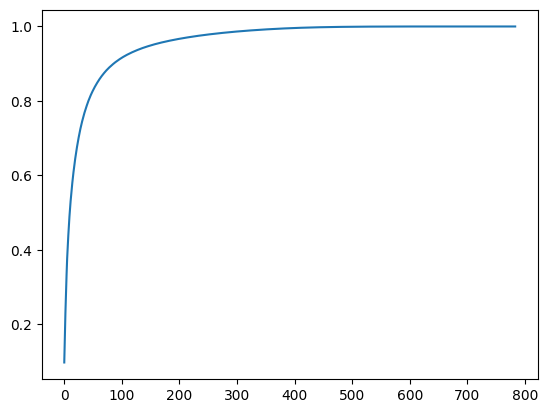

In [78]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))